##### <b>Details:</b> You will work with a dataset containing medical records of  treated with Radioactive Iodine (RAI) therapy. You aim to explore the dataset, perform basic analysis, and build a model to .  
##### <b>Objective:</b> Predict whether thyroid cancer will recur (Recurred: Yes/No) based on patient and clinical features.

#### <font color = #7FFFD4>  1. Load and Explore the Dataset</font>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import seaborn as sns
from sklearn import datasets

In [2]:
df=pd.read_csv('filtered_thyroid_data.csv')
df.head()

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


## EDA
#### 1. Structure

In [3]:
df.shape

(383, 13)

In [4]:
df.columns

Index(['Age', 'Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred'],
      dtype='object')

In [5]:
df.info

<bound method DataFrame.info of      Age Gender Hx Radiothreapy Adenopathy       Pathology     Focality  Risk  \
0     27      F              No         No  Micropapillary    Uni-Focal   Low   
1     34      F              No         No  Micropapillary    Uni-Focal   Low   
2     30      F              No         No  Micropapillary    Uni-Focal   Low   
3     62      F              No         No  Micropapillary    Uni-Focal   Low   
4     62      F              No         No  Micropapillary  Multi-Focal   Low   
..   ...    ...             ...        ...             ...          ...   ...   
378   72      M             Yes      Right       Papillary    Uni-Focal  High   
379   81      M             Yes  Extensive       Papillary  Multi-Focal  High   
380   72      M              No  Bilateral       Papillary  Multi-Focal  High   
381   61      M             Yes  Extensive    Hurthel cell  Multi-Focal  High   
382   67      M              No  Bilateral       Papillary  Multi-Focal  High

#### 2. Summary

In [6]:
df.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


In [7]:
df.describe(include='object')

,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
count,383,383,383,383,383,383,383,383,383,383,383,383
unique,2,2,6,4,2,3,7,3,2,5,4,2
top,F,No,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
freq,312,376,277,287,247,249,151,268,365,333,208,275


#### 3.Target Variable Balance Check

In [8]:
df['Recurred'].value_counts()

Recurred
No     275
Yes    108
Name: count, dtype: int64

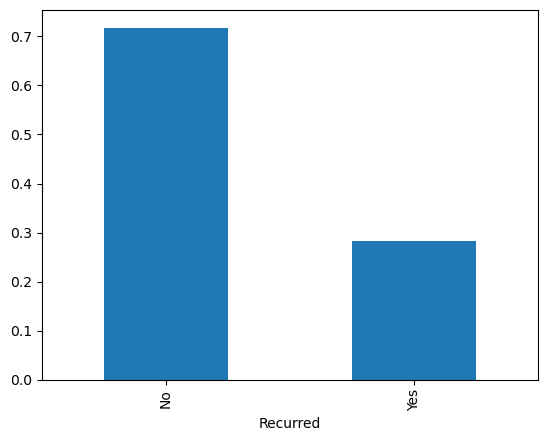

In [10]:
df['Recurred'].value_counts(normalize=True).plot(kind='bar')
plt.show()

#### 4.Missing Values Check

In [11]:
df.isnull().sum()

Age                0
Gender             0
Hx Radiothreapy    0
Adenopathy         0
Pathology          0
Focality           0
Risk               0
T                  0
N                  0
M                  0
Stage              0
Response           0
Recurred           0
dtype: int64

#### 5. Categorical Variables Check

In [13]:
cv = df.select_dtypes(include='object').columns
for col in cv:
    print(f"{col}:")
    print(df[col].value_counts())
    print("-" * 30)

Gender:
Gender
F    312
M     71
Name: count, dtype: int64
------------------------------
Hx Radiothreapy:
Hx Radiothreapy
No     376
Yes      7
Name: count, dtype: int64
------------------------------
Adenopathy:
Adenopathy
No           277
Right         48
Bilateral     32
Left          17
Extensive      7
Posterior      2
Name: count, dtype: int64
------------------------------
Pathology:
Pathology
Papillary         287
Micropapillary     48
Follicular         28
Hurthel cell       20
Name: count, dtype: int64
------------------------------
Focality:
Focality
Uni-Focal      247
Multi-Focal    136
Name: count, dtype: int64
------------------------------
Risk:
Risk
Low             249
Intermediate    102
High             32
Name: count, dtype: int64
------------------------------
T:
T
T2     151
T3a     96
T1a     49
T1b     43
T4a     20
T3b     16
T4b      8
Name: count, dtype: int64
------------------------------
N:
N
N0     268
N1b     93
N1a     22
Name: count, dtype: int64
-----

#### 6. Correlation Matrix

In [16]:
df.corr

<bound method DataFrame.corr of      Age Gender Hx Radiothreapy Adenopathy       Pathology     Focality  Risk  \
0     27      F              No         No  Micropapillary    Uni-Focal   Low   
1     34      F              No         No  Micropapillary    Uni-Focal   Low   
2     30      F              No         No  Micropapillary    Uni-Focal   Low   
3     62      F              No         No  Micropapillary    Uni-Focal   Low   
4     62      F              No         No  Micropapillary  Multi-Focal   Low   
..   ...    ...             ...        ...             ...          ...   ...   
378   72      M             Yes      Right       Papillary    Uni-Focal  High   
379   81      M             Yes  Extensive       Papillary  Multi-Focal  High   
380   72      M              No  Bilateral       Papillary  Multi-Focal  High   
381   61      M             Yes  Extensive    Hurthel cell  Multi-Focal  High   
382   67      M              No  Bilateral       Papillary  Multi-Focal  High

## Data Cleaning And Preprocessing
#### Encoding (Encode categorical variables using one-hot encoding)

In [19]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#### Split features and target

In [20]:
X = df_encoded.drop(columns=['Recurred_Yes'])  # Target: Recurred_Yes
y = df_encoded['Recurred_Yes']

#### Split into train and test sets 

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Feature Scaling

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 1. Baseline Model - Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

       False       0.98      1.00      0.99        58
        True       1.00      0.95      0.97        19

    accuracy                           0.99        77
   macro avg       0.99      0.97      0.98        77
weighted avg       0.99      0.99      0.99        77



## 2. Advanced Model - XGBoost

In [24]:
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.97      0.97        58
        True       0.90      0.95      0.92        19

    accuracy                           0.96        77
   macro avg       0.94      0.96      0.95        77
weighted avg       0.96      0.96      0.96        77



c:\Users\roger\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:06:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Hyperparameter Tuning

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param={'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

In [32]:
rf = RandomForestClassifier(random_state=42)


In [33]:
grid=GridSearchCV(rf,param_grid=param,cv=5,scoring='f1')

In [34]:
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [35]:
grid.best_params_

{'max_depth': None,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

In [38]:
be=grid.best_estimator_

In [39]:
y_pred_tuned = be.predict(X_test_scaled)

In [40]:
print(classification_report(y_test, y_pred_tuned, target_names=["No Recurrence", "Recurrence"]))

               precision    recall  f1-score   support

No Recurrence       0.98      1.00      0.99        58
   Recurrence       1.00      0.95      0.97        19

     accuracy                           0.99        77
    macro avg       0.99      0.97      0.98        77
 weighted avg       0.99      0.99      0.99        77



#### Precision, Recall, F1-score Bar Plot  

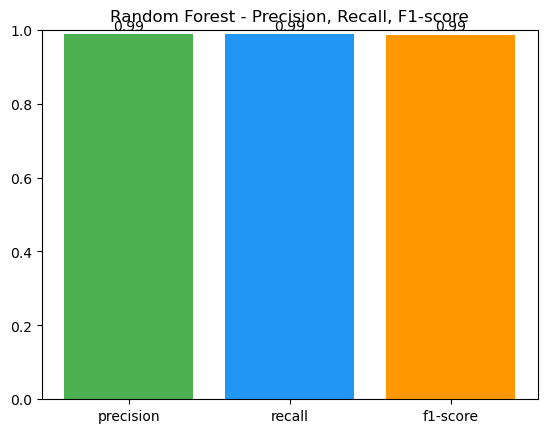

In [42]:
def plot_metrics_bar(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    scores = report["weighted avg"]
    metrics = ["precision", "recall", "f1-score"]
    values = [scores[m] for m in metrics]

    plt.bar(metrics, values, color=["#4CAF50", "#2196F3", "#FF9800"])
    plt.ylim(0, 1)
    plt.title(f"{model_name} - Precision, Recall, F1-score")
    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
    plt.show()

plot_metrics_bar(y_test, y_pred_rf, "Random Forest")

## Visualization
#### Confusion Matrix

<Figure size 1000x800 with 0 Axes>

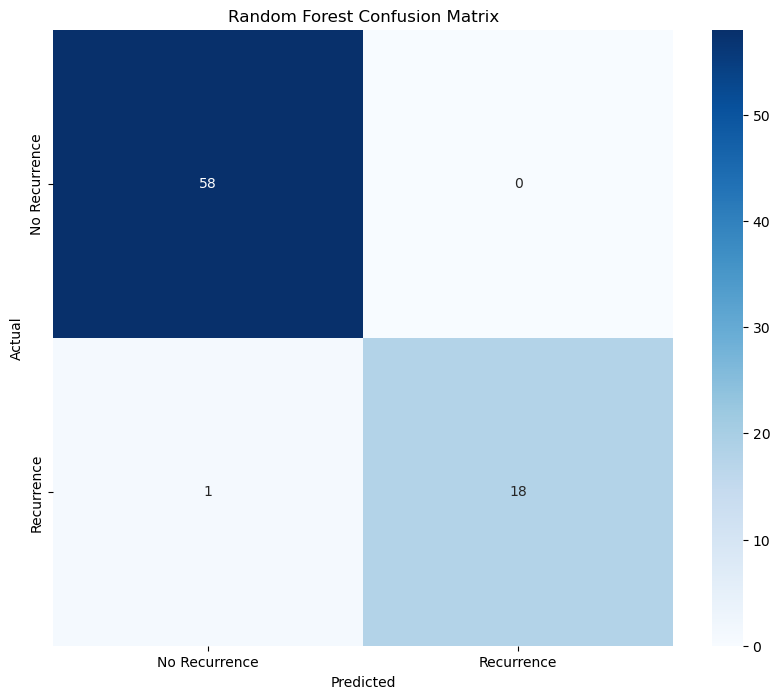

In [41]:
from sklearn.metrics import confusion_matrix, classification_report

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Recurrence", "Recurrence"],
                yticklabels=["No Recurrence", "Recurrence"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")